In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import joblib

In [2]:
from google.colab import files

uploaded = files.upload()

Saving titanic.csv to titanic.csv


In [4]:
df = pd.read_csv("titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [7]:
df['FamilySize'] = df['SibSp'] + df['Parch']

df['Cabin_Present'] = df['Cabin'].notnull().astype(int)

df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

df.head()

<>:5: SyntaxWarning: invalid escape sequence '\.'
<>:5: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_13279/229952841.py:5: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Cabin_Present,Title
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0,0,Mr
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,1,0,Mrs
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0,0,Mr
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0,0,Mr
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,2,0,Mrs


In [9]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("Missing values handled successfully")

Missing values handled successfully


In [10]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Cabin_Present,Title
0,0,3,male,34.5,0,0,7.8292,Q,0,0,Mr
1,1,3,female,47.0,1,0,7.0000,S,1,0,Mrs
2,0,2,male,62.0,0,0,9.6875,Q,0,0,Mr
3,0,3,male,27.0,0,0,8.6625,S,0,0,Mr
4,1,3,female,22.0,1,1,12.2875,S,2,0,Mrs


In [11]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Cabin_Present,Title
0,0,3,1,34.5,0,0,7.8292,1,0,0,5
1,1,3,0,47.0,1,0,7.0000,2,1,0,6
2,0,2,1,62.0,0,0,9.6875,1,0,0,5
3,0,3,1,27.0,0,0,8.6625,2,0,0,5
4,1,3,0,22.0,1,1,12.2875,2,2,0,6


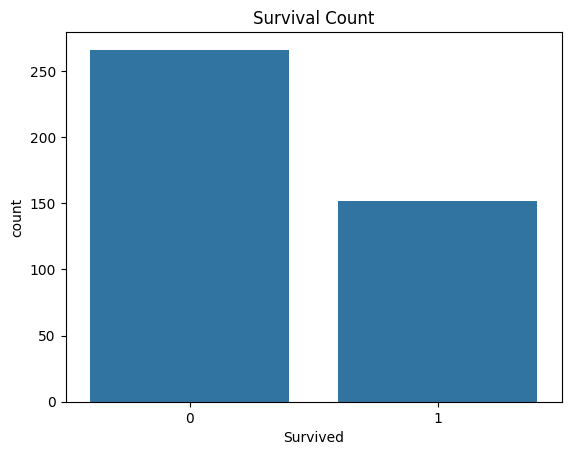

In [12]:
sns.countplot(x='Survived', data=df)

plt.title("Survival Count")

plt.show()

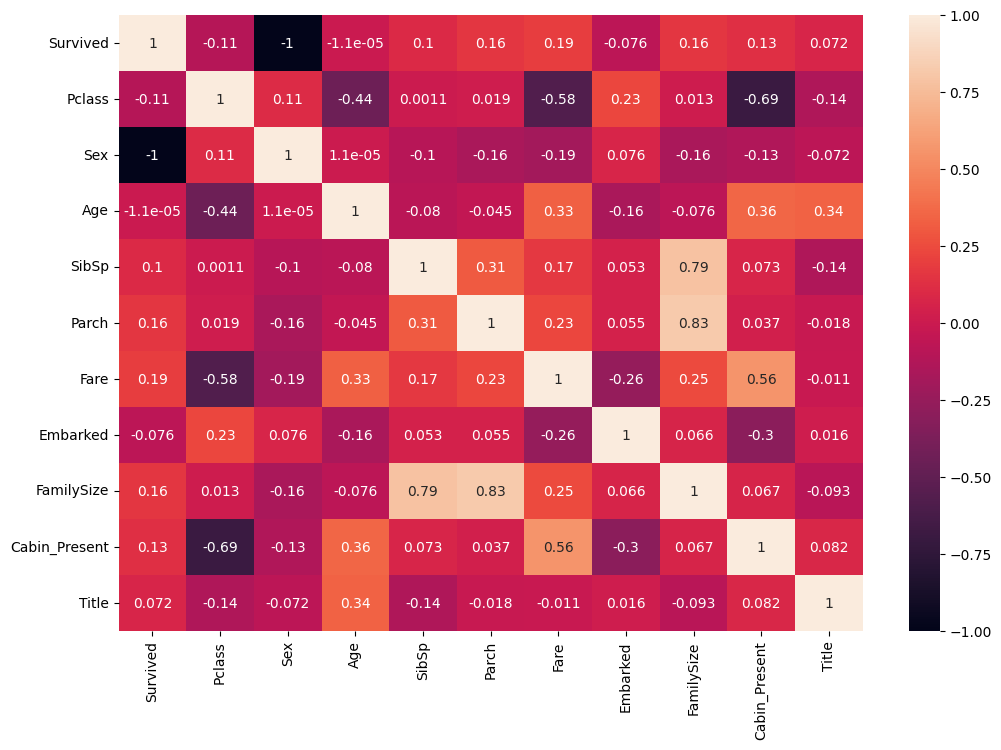

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True)

plt.show()

In [14]:
X = df.drop('Survived', axis=1)

y = df['Survived']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [17]:
acc = accuracy_score(y_test, pred)

print("Accuracy:", acc)

Accuracy: 1.0


In [18]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [19]:
cm = confusion_matrix(y_test, pred)

print(cm)

[[50  0]
 [ 0 34]]


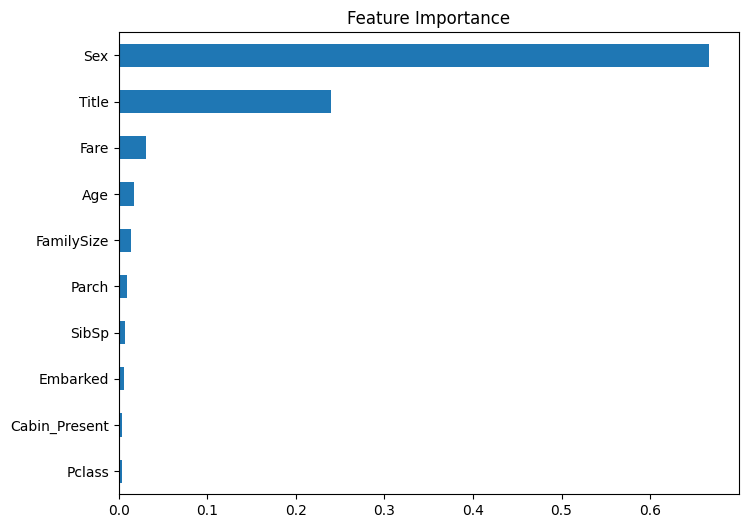

In [20]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Importance")

plt.show()

In [21]:
joblib.dump(model, "titanic_task3_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [22]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print("Predicted Survival:", prediction[0])

Predicted Survival: 0


In [23]:
files.download("titanic_task3_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>